In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="2,3"

%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys


PROJECT_ROOT = os.getcwd()
if os.path.basename(PROJECT_ROOT) == "notebooks_causal_cactus":
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.DataReaders import *
from src.address import *
from src.modelGen import *
from src.utils import cf_eval, cleanup_gpu, LOF_context_score
from models import CF_CausalCondLatentCF, CF_LatentCFpp, CF_PrototypeCF, CF_CondLatentCF
import numpy as np
import random 
from tensorflow import random as tf_random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
import argparse
import pandas as pd
import tensorflow as tf



2026-06-15 17:58:33.292993: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
SEED = 23

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf_random.set_seed(SEED)


CF_METHODS = {  
    "LatentCFpp": CF_LatentCFpp,
    "Prototype": CF_PrototypeCF,
    "CausalCACTUS": CF_CausalCondLatentCF,
    "CACTUS": CF_CondLatentCF
}


In [4]:
# Experimentos a realizar
EXP_CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "experiments", "ADULT_EXP.json")
with open(EXP_CONFIG_PATH, encoding="utf-8") as f:
    EXP = json.load(f)


In [5]:
# Loading data
CLASS_CONFIG_PATH = EXP[0]["classifier"]
class_config = get_exp_config(CLASS_CONFIG_PATH)
data   = getData(class_config)

# Getting the classifier
classifier = modelGen(class_config["type"], data,params=class_config, debug=True)
classifier.load()

/home/diego/repositorios/tabular-causal-counterfactuals/src/DataReaders/DataReader_Adult.py:115: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(self.context["sex"]))
/home/diego/repositorios/tabular-causal-counterfactuals/src/DataReaders/DataReader_Adult.py:116: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(self.context["race"]))
2026-06-15 17:59:10.581403: E tensorflow/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-06-15 17:59:10.581423: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: Aegon
2026-06-15 17:59:10.581428: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: Aegon
2026-06-15 17:59:10.581534: I tensorflow

sex
1    20380
0     9782
Name: count, dtype: int64
race
1    25933
0     4229
Name: count, dtype: int64




----------------------------------------------------------------------------------------------------
---- DATA SUMMARY ----
Total samples: 15016
Positive class (>50K): 7508.0
Context 'sex=Male': 10996
Context 'race=White': 13129
----------------------------------------------------------------------------------------------------




Building model
Building model: Classifier_DNN [class]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 main_input (InputLayer)     [(None, 7)]               0         
                                                                 
 dense (Dense)               (None, 64)                512       
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)            

In [10]:
context_test

,sex,race
16036,1,1
803,1,1
5061,1,1
7536,1,1
13884,1,1
...,...,...
19439,0,0
14664,1,1
79,1,1
20717,1,1


In [11]:
# Select test data
X_test = data.X_test
y_test_onehot = data.y_test
context_test = data.context_test

context_labels = ["Female","Male"]

X_original = []
y_original_onehot = []
context_original = []

N = 5
SELECTED_IDX = []

for val, lbl in enumerate(context_labels):
    idx = np.argwhere(context_test["sex"].values == val)[:,0]
    idx = np.random.choice(idx, N)

    SELECTED_IDX += idx.tolist()

    X_original.append(X_test[idx])
    y_original_onehot.append(y_test_onehot[idx])
    context_original.append(context_test.values[idx])

X_original = np.vstack(X_original)
y_original_onehot = np.vstack(y_original_onehot)
context_original = np.vstack(context_original)

lof_original = LOF_context_score(
    data.X_train,
    data.context_train.values,
    X_original,
    context_original,
    agg=False
)

In [8]:
""" Naming human-matched
X => X_test
Y => y_test
context => context_test
X_0 => X_original
Y_0 => y_original_onehot
context_0 => context_original
LOF_0 => lof_original

X_k => X_cf_list
Y_k_ => y_cf_labels_list
X => X_internal_list
Y_ => y_internal_list
LOF_k => lof_cf_list

Y_0_ => y_original_labels
Y_0_logit => y_original_logits

x_k => X_cf
y_k_ => y_cf_labels
x => X_internal
y_ => y_internal
lof_k => lof_cf
""" 
# pd.set_option('display.float_format', lambda x: f'%.{len(str(x%1))-2}f' % x)
# np.set_printoptions(suppress=True, precision=6)


' Naming human-matched\nX => X_test\nY => y_test\ncontext => context_test\nX_0 => X_original\nY_0 => y_original_onehot\ncontext_0 => context_original\nLOF_0 => lof_original\n\nX_k => X_cf_list\nY_k_ => y_cf_labels_list\nX => X_internal_list\nY_ => y_internal_list\nLOF_k => lof_cf_list\n\nY_0_ => y_original_labels\nY_0_logit => y_original_logits\n\nx_k => X_cf\ny_k_ => y_cf_labels\nx => X_internal\ny_ => y_internal\nlof_k => lof_cf\n'

In [12]:
import re
from collections import defaultdict
# TODO: make a function to convert the causal paths for all the test samples
def build_causal_index_map(input_features, graph_str):
    """
    Returns:
        child_to_parents: dict {child_idx: [parent_idx, ...]}
        parent_to_children: dict {parent_idx: [child_idx, ...]}
        feat2idx: dict {feature_name: index}
    """

    # Feature name to index
    feat2idx = {f: i for i, f in enumerate(input_features)}

    # Extract edges using regex
    edges = re.findall(r'(\w+)\s*->\s*(\w+)', graph_str)

    child_to_parents = defaultdict(list)
    parent_to_children = defaultdict(list)

    for parent, child in edges:

        if parent not in feat2idx or child not in feat2idx:
            raise ValueError(f"Feature in graph not found in dataset: {parent} or {child}")

        p_idx = feat2idx[parent]
        c_idx = feat2idx[child]

        child_to_parents[c_idx].append(p_idx)
        parent_to_children[p_idx].append(c_idx)

    return dict(child_to_parents), dict(parent_to_children), feat2idx




# 
graph_str2 = """ 
strict digraph {
educationnum;
workclass;
occupation;
capitalloss;
sex;
race;
capitalgain;
hoursperweek;
maritalstatus;
workclass -> hoursperweek;
workclass -> occupation;
capitalgain -> hoursperweek;
capitalgain -> occupation;
hoursperweek -> occupation;
}
"""

In [13]:
SEED = 12

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#########
# Context-preserving CF generation
#########
X_cf_list = []
y_cf_labels_list = []
X_internal_list = []
y_internal_list = []
lof_cf_list = []
cf_scores_list = []
cf_scores_labels_list = []

for exp_id, exp in enumerate(EXP):

    AE_CONFIG_PATH = exp["AEmodel"]
    AE_config = get_exp_config(AE_CONFIG_PATH)

    ae_model = modelGen(
        AE_config["type"],
        data,
        params=AE_config,
        debug=True
    )
    ae_model.load()

    y_original_labels = np.argmax(y_original_onehot, axis=1)
    y_original_logits = classifier.predict(X_original)

    # NOTE: updated
    child_to_parents_dict, parent_to_children_dict, feat2idx = build_causal_index_map(
        data.features_lbls,
        graph_str2
    )
    print("Feature → index:")
    print(feat2idx)
    print("\nChild → Parents (index form):")
    print(child_to_parents_dict)

    if exp["name"] == "CausalCACTUS":
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train,
            x_min=data.X_train.min(axis=0),
            x_max=data.X_train.max(axis=0),
            causal_index_map=child_to_parents_dict
        )
    else:
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train
        )

    X_cf, y_cf_labels, X_internal, y_internal = CF_method.transform(
        X_original,
        y_original_labels,
        target_context=context_original
    )

    lof_cf = LOF_context_score(
        data.X_train,
        data.context_train.values,
        X_cf,
        context_original,
        agg=False
    )
    
    # --- CF evaluation ---
    cf_scores, cf_scores_labels = cf_eval(
        X_train=data.X_train, # previous name: data.X_train
        context_train=data.context_train, # previous name: context_training,
        X=X_internal, # previous name: x,
        CF_X=X_cf, # previous name: cf_x, 
        pred_labels=y_original_labels, # previous name: y_,
        target_context=context_original, # previous name: context,
        CF_labels=y_cf_labels, # previous name: cf_y_
        X_unscaled=data.scaler_inverse_transform(X_internal),
        CF_X_unscaled=data.scaler_inverse_transform(X_cf),
        child_to_parents_dict=child_to_parents_dict,
        average=False
    )

    # X_cf = data.scaler_inverse_transform(X_cf) # TODO: non scale

    X_cf_list.append(X_cf)
    y_cf_labels_list.append(y_cf_labels)
    X_internal_list.append(X_internal)
    y_internal_list.append(y_internal)
    lof_cf_list.append(lof_cf)
    cf_scores_list.append(cf_scores)
    cf_scores_labels_list.append(cf_scores_labels)

    cleanup_gpu()


Building model
Building model: AE_TABULAR [gen]
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 main_input (InputLayer)     [(None, 7)]               0         
                                                                 
 model_1 (Functional)        (None, 16)                4640      
                                                                 
 model_2 (Functional)        (None, 7)                 4631      
                                                                 
Total params: 9,271
Trainable params: 9,271
Non-trainable params: 0
_________________________________________________________________
restoring weights of model AE_TABULAR: ADULT_AE


/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer VarianceScaling is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


1/1 [==============================] - 0s 91ms/step
Feature → index:
{'educationnum': 0, 'workclass': 1, 'occupation': 2, 'hoursperweek': 3, 'capitalgain': 4, 'capitalloss': 5, 'maritalstatus': 6}

Child → Parents (index form):
{3: [1, 4], 2: [1, 4, 3]}
Building model: latentCF [CF]
Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_input (InputLayer)        [(None, 16)]              0         
                                                                 
 model_2 (Functional)        (None, 7)                 4631      
                                                                 
 model (Functional)          (None, 2)                 35266     
                                                                 
Total params: 39,897
Trainable params: 39,129
Non-trainable params: 768
_________________________________________________________________
Generating CF 0/10
epoch 1/100 Ta

/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer VarianceScaling is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Epoch 0/100   Target cls 1  
Pred logit: [1.00,0.00] Best proto: False  c: 1.0 
L_pred: 1.00  L_dist: 256.62  L_AE: 0.00  L_proto: 46224.01  Loss: 8775.17 
Grad abs/mean: 892.51/892.51  Grad min/max: 247.58/1000.00 

Epoch 1/100   Target cls 1  
Pred logit: [0.97,0.03] Best proto: False  c: 1.0 
L_pred: 0.95  L_dist: 311.47  L_AE: 0.00  L_proto: 18481.48  Loss: 46477.79 
Grad abs/mean: 899.45/415.03  Grad min/max: -1000.00/1000.00 

Epoch 2/100   Target cls 1  
Pred logit: [1.00,0.00] Best proto: False  c: 1.0 
L_pred: 1.00  L_dist: 292.92  L_AE: 0.00  L_proto: 37144.97  Loss: 18790.44 
Grad abs/mean: 337.10/-20.24  Grad min/max: -964.99/768.32 

Epoch 3/100   Target cls 1  
Pred logit: [0.57,0.43] Best proto: False  c: 1.0 
L_pred: 0.15  L_dist: 343.03  L_AE: 0.00  L_proto: 34555.49  Loss: 37435.77 
Grad abs/mean: 883.91/-26.77  Grad min/max: -1000.00/1000.00 

Epoch 4/100   Target cls 1  
Pred logit: [1.00,0.00] Best proto: False  c: 1.0 
L_pred: 1.00  L_dist: 380.53  L_AE: 0.00  L_p

...

Epoch 0/100   Target cls 1  
Pred logit: [1.00,0.00] Best proto: False  c: 1.0 
L_pred: 1.00  L_dist: 256.60  L_AE: 8725.48  L_proto: 46226.33  Loss: 8775.48 
Grad abs/mean: 892.46/892.46  Grad min/max: 247.19/1000.00 

Epoch 1/100   Target cls 1  
Pred logit: [0.97,0.03] Best proto: False  c: 1.0 
L_pred: 0.95  L_dist: 311.47  L_AE: 9452.86  L_proto: 18481.48  Loss: 55205.57 
Grad abs/mean: 777.23/205.80  Grad min/max: -1000.00/1000.00 

Epoch 2/100   Target cls 1  
Pred logit: [0.20,0.80] Best proto: True  c: 1.0 
L_pred: 0.00  L_dist: 185.41  L_AE: 2991.85  L_proto: 47984.72  Loss: 28243.30 
Grad abs/mean: 728.83/-520.02  Grad min/max: -1000.00/573.85 

Epoch 3/100   Target cls 1  
Pred logit: [0.44,0.56] Best proto: True  c: 1.0 
L_pred: 0.00  L_dist: 134.67  L_AE: 6676.54  L_proto: 15181.26  Loss: 51158.84 
Grad abs/mean: 888.30/254.56  Grad min/max: -1000.00/1000.00 

Epoch 4/100   Target cls 1  
Pred logit: [0.98,0.02] Best proto: True  c: 1.0 
L_pred: 0.96  L_dist: 136.90  L_AE

/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer VarianceScaling is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


_________________________________________________________________
epoch 1/300 Target [0.5] Target cls 1 Context target [0. 1.] Best False Alpha 0.70
Pred logit [0.86,0.14] Pred context [0.67,0.84]
Dist. 0.87 Val loss 1.24  Context loss 0.63 Loss 1.16 
Grad mean/abs -0.10562211275100708/0.4086403250694275  Grad min/max -0.62/0.61
Best False   Best prob. 0.30  Best dist. 10000000000.00 Best context [0.67,0.84]

epoch 2/300 Target [0.5] Target cls 1 Context target [0. 1.] Best False Alpha 0.70
Pred logit [0.85,0.15] Pred context [0.66,0.84]
Dist. 0.88 Val loss 1.22  Context loss 0.63 Loss 1.14 
Grad mean/abs -0.10626779496669769/0.3850538730621338  Grad min/max -0.58/0.56
Best False   Best prob. 0.30  Best dist. 10000000000.00 Best context [0.67,0.84]

epoch 3/300 Target [0.5] Target cls 1 Context target [0. 1.] Best False Alpha 0.70
Pred logit [0.85,0.15] Pred context [0.66,0.84]
Dist. 0.89 Val loss 1.21  Context loss 0.63 Loss 1.13 
Grad mean/abs -0.11495614796876907/0.27904361486434937

/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer VarianceScaling is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
/home/diego/anaconda/yes/envs/cactus-env/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


                                                                 
 model (Functional)          (None, 2)                 35266     
                                                                 
Total params: 36,713
Trainable params: 0
Non-trainable params: 36,713
_________________________________________________________________
i_sample/N_samples: 0/10
#epoch 1/300.
self.alpha: 0.99. self.gamma: 0.1
Valid False. Best False.
Pred logits: [0.86,0.14] Target prob [0.5] Target cls 1 
Pred context: [0.67,0.84] Target ctx [[0. 1.]]
Raw Dist loss 0.87 Val loss 1.24  Context loss 0.63 
Scaled Dist loss 0.09 Val loss 1.23  Context loss 0.01; Loss total 1.34 
Grad mean/abs -0.17/0.61  Grad min/max -0.82/0.88
Best prob. 0.30 Best val. 10000000000.00 Best dist. 10000000000.00 Best context 10000000000.00

i_sample/N_samples: 0/10
#epoch 2/300.
self.alpha: 0.99. self.gamma: 0.1
Valid False. Best False.
Pred logits: [0.85,0.15] Target prob [0.5] Target cls 1 
Pred context: [0.67,0.84] Target ctx 

In [14]:
print(X_cf_list[0].shape)

print(len(X_cf_list))

(10, 7)
5


In [15]:
print([exp_i["name"] for exp_i in EXP])

['LatentCF++', 'Prototype C', 'Prototype D', 'CACTUS', 'CausalCACTUS']


In [16]:
pd.DataFrame(cf_scores_list, columns=cf_scores_labels_list[0])

,proximity,n_proximity,validity,compactness,lof_context,causal_validity_hard,causal_validity_soft,causal_compact_val,inlier_fraction
0,3.121085,1.179659,1.0,0.000000,"[1.3104867569788892, 1.051676968989024, 1.3970...","[True, True, True, True, True, True, True, Tru...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.2857142857142857, 0.14285714285714285, 0.28...","[1.0, 1.0, 1.0]"
1,7.148551,2.701898,1.0,0.042857,"[2.571801282095279, 2.829113507386785, 1.51910...","[True, True, True, True, True, True, True, Tru...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.14285714285714285, 0.0, 0.14285714285714285...","[0.2, 0.0, 0.5]"
2,6.630055,2.505925,1.0,0.042857,"[1.762769600815839, 2.119602527023638, 2.06402...","[True, True, True, True, True, True, True, Tru...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.14285714285714285, 0.14285714285714285, 0.0...","[0.2, 0.0, 0.0]"
3,1.592829,0.602033,0.6,0.114286,"[1.0976305981171703, 1.194279826200046, 1.1522...","[True, True, True, True, True, True, True, Tru...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.14285714285714285, 0.14285714285714285, 1.0...","[1.0, 1.0, 1.0]"
4,1.456956,0.550678,0.9,0.142857,"[1.2087361774709344, 1.1230094441893896, 1.152...","[True, True, True, True, True, True, True, Tru...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.14285714285714285, 0.42857142857142855, 1.0...","[1.0, 1.0, 1.0]"


# Heat map $\Delta(x)$ (with normalized data)
Delta heatmap without dernormalizing the data

In [17]:
## Setting up data
# Original samples "scaled"
print(X_original.shape)
# List for all CF generated in all exps
print(len(X_cf_list))
# List of exps
print([exp["name"] for exp in EXP])
# List of feats
print(data.features_lbls)
# Original samples 
X_original_unscaled = data.scaler_inverse_transform(X_original)
# Denormalized CF samples 
X_cf_unscaled_list = [data.scaler_inverse_transform(x_cf)  for x_cf in X_cf_list] 

(10, 7)
5
['LatentCF++', 'Prototype C', 'Prototype D', 'CACTUS', 'CausalCACTUS']
['educationnum', 'workclass', 'occupation', 'hoursperweek', 'capitalgain', 'capitalloss', 'maritalstatus']


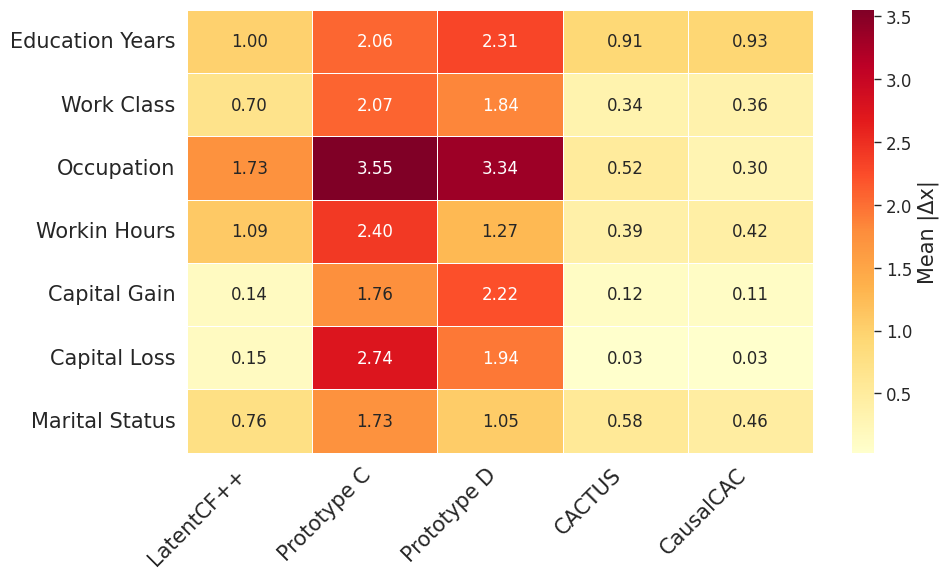

In [ ]:
import seaborn as sns

# -----------------------------
# Compute aggregated |Δx|
# -----------------------------

feature_names = [ 				
"Education Years",
 "Work Class",
 'Occupation',
 'Working Hours',    
 'Capital Gain',
 'Capital Loss',
 'Marital Status']


exp_names = ["LatentCF++", "Prototype C","Prototype D","CACTUS","CausalCAC"]

agg_deltas = []

for x_cf in X_cf_list:
    delta = np.abs(x_cf - X_original)   # |Δx|
    agg_deltas.append(delta.mean(axis=0))        # aggregate over samples
    

# Shape: (num_experiments, num_features)
agg_deltas = np.vstack(agg_deltas)
agg_deltas = np.round(agg_deltas,2)
# Create DataFrame (features as rows, experiments as columns)
df_heatmap = pd.DataFrame(
    agg_deltas.T,
    index=feature_names,
    columns=exp_names
)

# -----------------------------
# Seaborn / Matplotlib paper style
# -----------------------------
sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.4   # escala global (ajustable)
)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    df_heatmap,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean |Δx|"},
    annot_kws={"size": 12}   # números dentro del heatmap
)


# Tick labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=15
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=15
)

# Colorbar label & ticks
cbar = ax.collections[0].colorbar
cbar.set_label("Mean |Δx|", fontsize=15)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

#TODO indicate the graph structure in the Heatmap

In [25]:
# strict digraph {
# NumberRealEstateLoansOrLines;
# NumberOfTimes90DaysLate;
# NumberOfDependents;
# age;
# DebtRatio;
# NumberOfTime3059DaysPastDueNotWorse;
# NumberOfOpenCreditLinesAndLoans;
# RevolvingUtilizationOfUnsecuredLines;
# MonthlyIncome;
# NumberOfTime6089DaysPastDueNotWorse;
# NumberOfTimes90DaysLate -> NumberOfOpenCreditLinesAndLoans;
# NumberOfTimes90DaysLate -> NumberRealEstateLoansOrLines;
# NumberOfTimes90DaysLate -> RevolvingUtilizationOfUnsecuredLines;
# NumberOfTimes90DaysLate -> MonthlyIncome;
# NumberOfTime3059DaysPastDueNotWorse -> NumberOfOpenCreditLinesAndLoans;
# NumberOfTime3059DaysPastDueNotWorse -> NumberRealEstateLoansOrLines;
# NumberOfTime3059DaysPastDueNotWorse -> MonthlyIncome;
# NumberOfOpenCreditLinesAndLoans -> DebtRatio;
# RevolvingUtilizationOfUnsecuredLines -> NumberOfOpenCreditLinesAndLoans;
# MonthlyIncome -> NumberOfOpenCreditLinesAndLoans;
# }

In [21]:
print(child_to_parents_dict)
for i,feat in enumerate(feature_names):
    print(f"{i}:{feat}")

{3: [1, 4], 2: [1, 4, 3]}
0:Education Years
1:Work Class
2:Occupation
3:Workin Hours
4:Capital Gain
5:Capital Loss
6:Marital Status


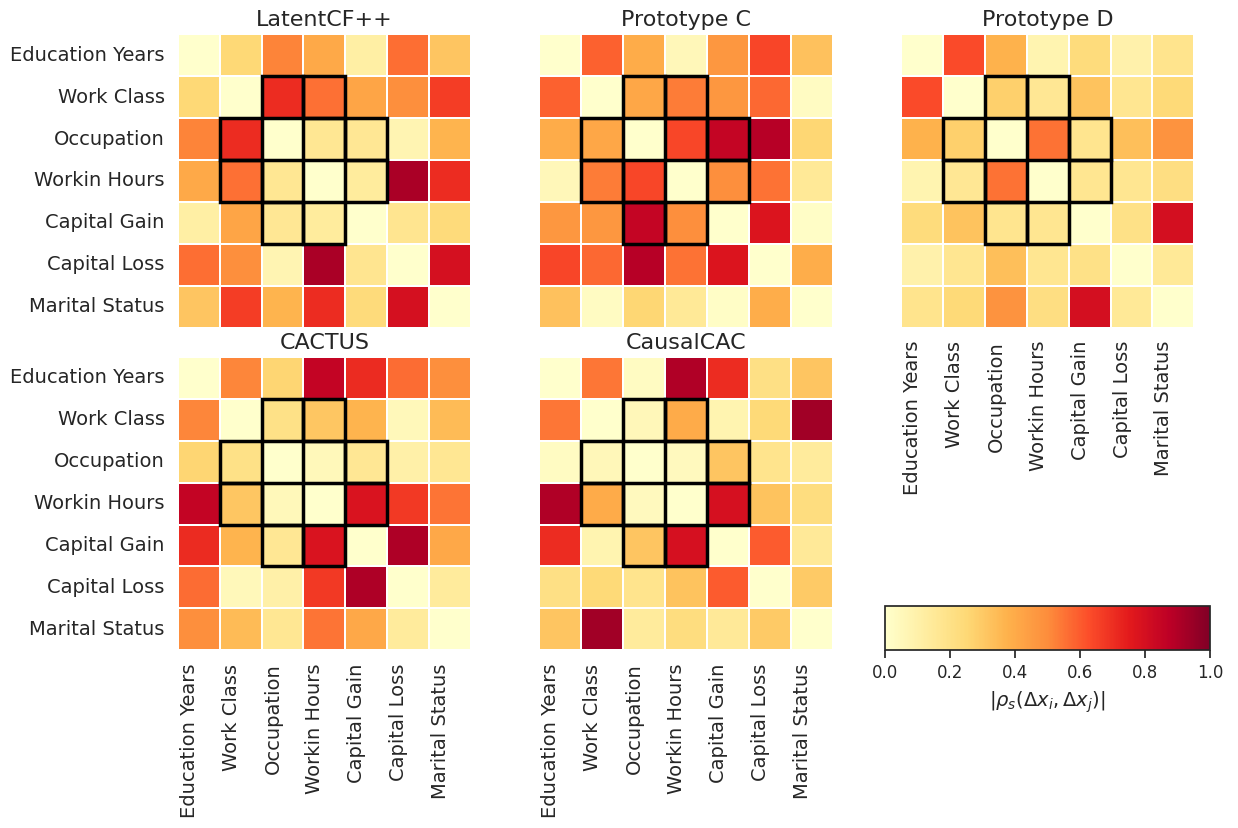

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# Setup
# -----------------------------
feature_names = [ 				
"Education Years",
 "Work Class",
 'Occupation',
 'Workin Hours',    
 'Capital Gain',
 'Capital Loss',
 'Marital Status']

exp_names = ["LatentCF++", "Prototype C","Prototype D","CACTUS","CausalCAC"]
d = X_original_unscaled.shape[1]

# Build list of (row, col) indices to highlight
highlight_pairs = []
for child, parents in child_to_parents_dict.items():
    for parent in parents:
        highlight_pairs.append((child, parent))   # (row=child, col=parent)
        highlight_pairs.append((parent, child))   # symmetric cell
highlight_pairs = list(set(highlight_pairs))      # remove duplicates

# -----------------------------
# Compute |Spearman| correlation matrices
# -----------------------------
corr_mats = []
for x_cf in X_cf_list:
    delta = x_cf - X_original
    corr, _ = spearmanr(delta, axis=0)
    corr = np.asarray(corr).reshape(d, d)
    C = np.abs(corr)
    np.fill_diagonal(C, 0.0)
    corr_mats.append(C)

# -----------------------------
# Plot (5 matrices) + colorbar in subplot 6
# -----------------------------
sns.set(style="white")

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    gridspec_kw={"wspace": 0.0, "hspace": 0.1}
)
axes = axes.flatten()

cmap = "YlOrRd"
vmin, vmax = 0.0, 1.0

# Plot only the first 5 heatmaps (leave axes[5] for the colorbar)
for i, (ax, name, C) in enumerate(zip(axes[:5], exp_names, corr_mats)):
    sns.heatmap(
        C,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=feature_names if i >= 2 else False,       # bottom row only
        yticklabels=feature_names if i % 3 == 0 else False,   # leftmost col only
        cbar=False,
        linewidths=0.3,
        linecolor="white",
    )

    # Highlight child-parent cells with rectangles
    for (r, c) in highlight_pairs:
        if 0 <= r < d and 0 <= c < d:
            ax.add_patch(
                Rectangle(
                    (c, r), 1, 1,
                    fill=False,
                    edgecolor="black",
                    linewidth=2.5
                )
            )

    if i >= 2:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

    ax.set_title(name, fontsize=16)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

# -----------------------------
# Put a THIN horizontal colorbar inside the 6th subplot (axes[5])
# -----------------------------
axes[5].axis("off")  # use only as a container

mappable = axes[0].collections[0]

# inset axis for a thin bar (won't cover subplot 3 xticks)
cax = inset_axes(
    axes[5],
    width="90%",      # relative to subplot 6
    height="15%",     # thin bar
    loc="lower center",
    borderpad=0.0
)

cbar = fig.colorbar(
    mappable,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(r"$|\rho_s(\Delta x_i,\Delta x_j)|$", fontsize=14, labelpad=6)
cbar.ax.tick_params(labelsize=12)

#plt.tight_layout()
plt.show()

In [29]:
# strict digraph {
# NumberRealEstateLoansOrLines;
# NumberOfTimes90DaysLate;
# NumberOfDependents;
# age;
# DebtRatio;
# NumberOfTime3059DaysPastDueNotWorse;
# NumberOfOpenCreditLinesAndLoans;
# RevolvingUtilizationOfUnsecuredLines;
# MonthlyIncome;
# NumberOfTime6089DaysPastDueNotWorse;
# NumberOfTimes90DaysLate -> NumberOfOpenCreditLinesAndLoans;
# NumberOfTimes90DaysLate -> NumberRealEstateLoansOrLines;
# NumberOfTimes90DaysLate -> RevolvingUtilizationOfUnsecuredLines;
# NumberOfTimes90DaysLate -> MonthlyIncome;
# NumberOfTime3059DaysPastDueNotWorse -> NumberOfOpenCreditLinesAndLoans;
# NumberOfTime3059DaysPastDueNotWorse -> NumberRealEstateLoansOrLines;
# NumberOfTime3059DaysPastDueNotWorse -> MonthlyIncome;
# NumberOfOpenCreditLinesAndLoans -> DebtRatio;
# RevolvingUtilizationOfUnsecuredLines -> NumberOfOpenCreditLinesAndLoans;
# MonthlyIncome -> NumberOfOpenCreditLinesAndLoans;
# }